# Classification Project- Will this Customer Churn?**

For his assignment using telecommunication dataset predict if customer will churn or not using two classification methods Random forect model and Logistic regression model.
At the end of each model give brief explaination of how model performed and write you own analysis on churn prediction and retention strategies. Give reasonings on what you think this model predicted and why?
Use visuals to show your findings and data along the way and ttach .ipynb and html files in final submission.

In [193]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# **Part I:  Random Forest Model**
***

In [194]:
telecomdf = pd.read_csv(r"C:\Users\jinal\Desktop\telecom_users.csv")

A. Read the dataset *telecom_users.csv* into Python.

In [195]:
telecomdf.head(10)

,Unnamed: 0,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1869,7010-BRBUU,Male,0,Yes,Yes,72,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.10,1734.65,No
1,4528,9688-YGXVR,Female,0,No,No,44,Yes,No,Fiber optic,...,Yes,No,Yes,No,Month-to-month,Yes,Credit card (automatic),88.15,3973.2,No
2,6344,9286-DOJGF,Female,1,Yes,No,38,Yes,Yes,Fiber optic,...,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),74.95,2869.85,Yes
3,6739,6994-KERXL,Male,0,No,No,4,Yes,No,DSL,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,55.90,238.5,No
4,432,2181-UAESM,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,Month-to-month,No,Electronic check,53.45,119.5,No
5,2215,4312-GVYNH,Female,0,Yes,No,70,No,No phone service,DSL,...,Yes,Yes,No,Yes,Two year,Yes,Bank transfer (automatic),49.85,3370.2,No
6,5260,2495-KZNFB,Female,0,No,No,33,Yes,Yes,Fiber optic,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,90.65,2989.6,No
7,6001,4367-NHWMM,Female,0,No,No,1,No,No phone service,DSL,...,No,No,No,No,Month-to-month,Yes,Mailed check,24.90,24.9,No
8,1480,8898-KASCD,Male,0,No,No,39,No,No phone service,DSL,...,Yes,Yes,No,No,One year,No,Mailed check,35.55,1309.15,No
9,5137,8016-NCFVO,Male,1,No,No,55,Yes,Yes,Fiber optic,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,116.50,6382.55,No


*B. Which of the variables here are categorical?  Which are numeric?*

*a. For your categorical input variables, do you need to take any steps to convert them into dummies, in order to build a classification model?  Why or why not?*

Ans: Categorical :           'customerID ',  'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'           
          
Numeric: 'tenure', 'MonthlyCharges','TotalCharges'


Here our output variable is Churn, which is categorical. Classification model can only deal with continous numeric input and output data and hence, we can't input a categorial value in it. Some implementations of machine learning algorithms require all data to be numerical. For example, scikit-learn has this requirement.Classification models can handle categorical variables only if you perform encoding on them. Here, we will perform conversion using get_dummies() function to assign 1 or 0 to the categories. Just Like 'SeniorCitizen' variable which is already dummified in this dataset where '1' indicates customer is a senior citizen and '0' indicates not a senior citizen. We will begin by cleaning and preparing data before dummifying variables for classification model.


In [196]:
#Cleaning the data:

telecomdf=telecomdf.drop("Unnamed: 0",axis=1)
telecomdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5986 entries, 0 to 5985
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5986 non-null   object 
 1   gender            5986 non-null   object 
 2   SeniorCitizen     5986 non-null   int64  
 3   Partner           5986 non-null   object 
 4   Dependents        5986 non-null   object 
 5   tenure            5986 non-null   int64  
 6   PhoneService      5986 non-null   object 
 7   MultipleLines     5986 non-null   object 
 8   InternetService   5986 non-null   object 
 9   OnlineSecurity    5986 non-null   object 
 10  OnlineBackup      5986 non-null   object 
 11  DeviceProtection  5986 non-null   object 
 12  TechSupport       5986 non-null   object 
 13  StreamingTV       5986 non-null   object 
 14  StreamingMovies   5986 non-null   object 
 15  Contract          5986 non-null   object 
 16  PaperlessBilling  5986 non-null   object 


In [197]:
# Converting total charges variable to numeric & Checking missing values
telecomdf.TotalCharges= pd.to_numeric(telecomdf.TotalCharges,errors='coerce')
telecomdf.isnull().sum().sum()

10

In [198]:
telecomdf.dropna(inplace=True)
telecomdf.isnull().sum().sum()

0

b. If you answered “yes” to the previous question, dummify any categorical inputs that require extra treatment now – but do not drop any levels.

In [199]:
# Dummifying categorical input variables:

telecom_dummies = pd.get_dummies(telecomdf,  columns = ['gender','Partner',
       'Dependents','PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling','PaymentMethod']) 
telecom_dummies.head()

,customerID,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7010-BRBUU,0,72,24.10,1734.65,No,0,1,0,1,...,0,0,0,1,1,0,0,1,0,0
1,9688-YGXVR,0,44,88.15,3973.20,No,1,0,1,0,...,0,1,0,0,0,1,0,1,0,0
2,9286-DOJGF,1,38,74.95,2869.85,Yes,1,0,0,1,...,0,1,0,0,0,1,1,0,0,0
3,6994-KERXL,0,4,55.90,238.50,No,0,1,1,0,...,1,1,0,0,0,1,0,0,1,0
4,2181-UAESM,0,2,53.45,119.50,No,0,1,1,0,...,0,1,0,0,1,0,0,0,1,0


C. Use a Label Encoder to convert the “Churn” values from “No” and “Yes” to 0 and 1 instead.

In [200]:
from sklearn import preprocessing

label_encoder = preprocessing.LabelEncoder()

telecom_dummies['Churn']= label_encoder.fit_transform(telecom_dummies['Churn'])
  
telecom_dummies['Churn'].unique()

telecom_dummies.head()

,customerID,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7010-BRBUU,0,72,24.10,1734.65,0,0,1,0,1,...,0,0,0,1,1,0,0,1,0,0
1,9688-YGXVR,0,44,88.15,3973.20,0,1,0,1,0,...,0,1,0,0,0,1,0,1,0,0
2,9286-DOJGF,1,38,74.95,2869.85,1,1,0,0,1,...,0,1,0,0,0,1,1,0,0,0
3,6994-KERXL,0,4,55.90,238.50,0,0,1,1,0,...,1,1,0,0,0,1,0,0,1,0
4,2181-UAESM,0,2,53.45,119.50,0,0,1,1,0,...,0,1,0,0,1,0,0,0,1,0


D. Use the `value_counts()` function from pandas to learn more about the outcome variable, Churn.  Next, run `value_counts()` again, but this time, including the `normalize=True` argument in the function.  *Describe your findings -- what are the different outcome classes here, and how common are each of them in the dataset?  What was different here about the second time you ran this function?*

In [201]:
telecom_dummies.value_counts("Churn")

Churn
0    4389
1    1587
dtype: int64

In [202]:
telecom_dummies.Churn.value_counts(normalize=True)

0    0.734438
1    0.265562
Name: Churn, dtype: float64

Outcome class 1 is 'Churn'= yes = cutomer left,  Outcome class 0 is 'Not Churn'= No = cutomer stayed

Describe: 
output 1:  raw counts of outcome class 0 and 1.
output 2:  compute the percent of total records of outcome class 0 and 1, using the normalize parameter.
          
Explaination: Output 1 shows total numbers of customers who churned are 1587 while the customer who stayed are 4389.In output 2 while using normalized parameter, But instead of showing the raw counts of each unique combination of categories, it’s showing the proportion. It tells 26.56% of customers churned while 73.44% customers stay.Notice that if you add all the numbers up, they add up to 1. The findings here tells us that majority of our customers are loyal with the company while there are still few customers who left. The churning of customers depends on different factors including price, tenure, service etc. The longer the contract duration the less likely it is that the customer will churn. Lower churning rate indicated most of the customers are satisfied with the service.

E. Partition the data, using any random_state value of your choice.  Assign 60% of rows to train, and 40% to test.  

*a. In one sentence, why did you choose this particular number for your random_state?*

In [203]:
telecom_dummies.columns

Index(['customerID', 'SeniorCitizen', 'tenure', 'MonthlyCharges',
       'TotalCharges', 'Churn', 'gender_Female', 'gender_Male', 'Partner_No',
       'Partner_Yes', 'Dependents_No', 'Dependents_Yes', 'PhoneService_No',
       'PhoneService_Yes', 'MultipleLines_No',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No', 'StreamingMovies_No internet service',
       'StreamingMovies_Yes', 'Contract_Month-to-month', 'Contract_One year',
      

In [204]:
X = telecom_dummies[['SeniorCitizen', 'tenure', 'MonthlyCharges',
       'TotalCharges', 'gender_Female', 'gender_Male', 'Partner_No',
       'Partner_Yes', 'Dependents_No', 'Dependents_Yes', 'PhoneService_No',
       'PhoneService_Yes', 'MultipleLines_No',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No', 'StreamingMovies_No internet service',
       'StreamingMovies_Yes', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year', 'PaperlessBilling_No', 'PaperlessBilling_Yes',
       'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']]
y = telecom_dummies['Churn']

In [205]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.4, random_state = 42)

Ans: We can use any integer including 0, but not negative ones, only positive integers. I chose 42 which is a popular  integer for random_state while using Scikit-learn, the function will produce the same results across different executions. The results are only changed if we change the integer value. 

F. Build a random forest model in Python with your training set.  Use `GridSearch_CV` to help you determine the best hyperparameter settings for your model.  

In [206]:
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

clf=RandomForestClassifier()
clf.fit(X_train,y_train)  

RandomForestClassifier()

In [207]:
feature_imp_df = pd.DataFrame(list(zip(clf.feature_importances_, X_train)))
feature_imp_df.columns = ['feature importance', 'feature']
feature_imp_df = feature_imp_df.sort_values(by='feature importance', ascending=False)
feature_imp_df

,feature importance,feature
3,0.157745,TotalCharges
1,0.137259,tenure
2,0.135734,MonthlyCharges
36,0.054168,Contract_Month-to-month
18,0.034523,OnlineSecurity_No
27,0.025412,TechSupport_No
43,0.024677,PaymentMethod_Electronic check
16,0.022070,InternetService_Fiber optic
38,0.021498,Contract_Two year
0,0.018975,SeniorCitizen


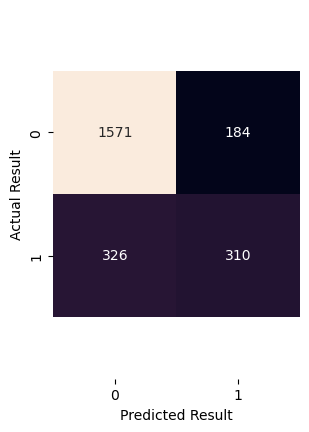

In [208]:
#Confusion Matrix
predictions = clf.predict(X_test)
mat = confusion_matrix(y_test, predictions)
sns.heatmap(mat, fmt='g', square=True, annot=True, cbar=False)
plt.xlabel("Predicted Result")
plt.ylabel("Actual Result")
a, b = plt.ylim() 
a += 0.5 
b -= 0.5 
plt.ylim(a, b)
plt.show()

In [209]:
# Prediction Accuracy score
y_pred = clf.predict(X_test)
print(metrics.accuracy_score(y_test, y_pred))

0.7867001254705144


In [210]:
from sklearn.model_selection import RandomizedSearchCV

# Create the random grid
param_grid={'n_estimators':[100,150,200], 
           'max_depth':[2,4,6,8], 
           'max_features':[4,7,12,18], 
           'min_samples_leaf':[2,4,6,10]}


In [211]:
from sklearn.model_selection import GridSearchCV

CV_rfc = GridSearchCV(estimator = clf, 
                      param_grid = param_grid, 
                      cv = 5)

CV_rfc.fit(X_train, y_train)

print(CV_rfc.best_params_)


{'max_depth': 8, 'max_features': 4, 'min_samples_leaf': 10, 'n_estimators': 200}


In [212]:
clf = RandomForestClassifier(n_estimators = 200, max_depth = 8, max_features = 4, min_samples_leaf = 10, random_state=42)
clf.fit(X_train,y_train)

RandomForestClassifier(max_depth=8, max_features=4, min_samples_leaf=10,
                       n_estimators=200, random_state=42)

*G. How did your random forest model rank the variables in order of importance, from highest to lowest?  For a random forest model, how can you interpret feature importance?*

In [213]:
feature_imp_df = pd.DataFrame(list(zip(clf.feature_importances_, X_train)))
feature_imp_df.columns = ['feature importance', 'feature']
feature_imp_df = feature_imp_df.sort_values(by='feature importance', ascending=False)
feature_imp_df

,feature importance,feature
1,0.134469,tenure
3,0.111117,TotalCharges
36,0.107143,Contract_Month-to-month
18,0.065727,OnlineSecurity_No
27,0.065105,TechSupport_No
2,0.053961,MonthlyCharges
16,0.052455,InternetService_Fiber optic
38,0.047328,Contract_Two year
43,0.038058,PaymentMethod_Electronic check
20,0.029913,OnlineSecurity_Yes


Ans: Random forest models can rank variables by importance by aggregating the individual decision trees' feature importances. The feature importances are computed based on the average reduction in impurity achieved by splitting the feature at each decision node in the trees of the forest.Feature Importance in a random forest model describe which features are relevant to the model and help in model improvement by employing model selection. The higher the impurity reduction, the more important the feature. Feature importance should be interpreted in the context of the problem at hand and the data being used in random forest model.For example, In our case model's given top 5 features as seen above, We can see price feature variables are on top of the list and it logically makes sense as an important feature to consider. While month to month contract and tenure are also considerably higher importance factor which makes sense for phone provider company's perspective.

H. Assess the performance of your model against the test set.  Build a confusion matrix to do this.  You can use Python functions to answer any of these questions or you can use your confusion matrix to determine the answers in a slightly more manual way.  The ‘positive’ class in this model is represented by the “1” outcome.   
*a. What is your model’s accuracy rate?*

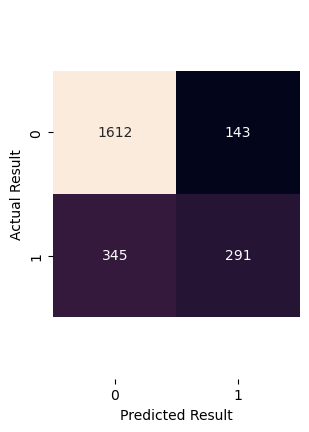

In [214]:
#confusion Matrix
predictions = clf.predict(X_test)
mat = confusion_matrix(y_test, predictions)
sns.heatmap(mat, fmt='g', square=True, annot=True, cbar=False)
plt.xlabel("Predicted Result")
plt.ylabel("Actual Result")
a, b = plt.ylim() 
a += 0.5 
b -= 0.5 
plt.ylim(a, b)
plt.show()

In [215]:
predictions = clf.predict(X_test)
print(metrics.classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.82      0.92      0.87      1755
           1       0.67      0.46      0.54       636

    accuracy                           0.80      2391
   macro avg       0.75      0.69      0.71      2391
weighted avg       0.78      0.80      0.78      2391



Model's accuracy rate is 80%.

*b. What is your model’s sensitivity rate?*

Model's sensitivity rate : 46% will churn(1), 92% will stay(0).

*c. What is your model’s specificity rate?*

Specificity rate : 1612/(1612+143)= 1612/1755 = 91.85%

*d. What is your model’s precision?*

Precision is likely to churn (1) is 67%, will stay (0) is 82%.

*e. What is your model’s balanced accuracy?*

Balanced accuracy = (0.92 + 0.46) / 2 = 0.69,  69% is model's balanced accuracy.

I. Compare your model’s accuracy against the training set vs. your model’s accuracy against the test set. *How different were these results?*

In [216]:
# Calculate the accuracy on the training set
train_accuracy = clf.score(X_train, y_train)
print("Accuracy on the training set: {:.2f}%".format(train_accuracy * 100))

# Calculate the accuracy on the test set
test_accuracy = clf.score(X_test, y_test)
print("Accuracy on the test set: {:.2f}%".format(test_accuracy * 100))


Accuracy on the training set: 81.45%
Accuracy on the test set: 79.59%


Ans: Model's accuracy rate for training data is higher than testing data. The purpose of this comparison is to determine whether the model has overfitted or underfitted to the training data.When the accuracy on the training set is higher than the accuracy on the test set, it generally indicates that the model is overfitting the training data. The accuracy rate for training set is 81% and on testing set accuracy is 79%. That means model is performing well on training data.

J. Invent a fictional telephone company subscriber.  Assign this subscriber a value for each predictor variable in this model, and store the results in a new dataframe.  Now, put your subscriber through this model.  
*a. What did your model predict -- will this subscriber churn?* 

In [217]:
telecom_dummies.columns

Index(['customerID', 'SeniorCitizen', 'tenure', 'MonthlyCharges',
       'TotalCharges', 'Churn', 'gender_Female', 'gender_Male', 'Partner_No',
       'Partner_Yes', 'Dependents_No', 'Dependents_Yes', 'PhoneService_No',
       'PhoneService_Yes', 'MultipleLines_No',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No', 'StreamingMovies_No internet service',
       'StreamingMovies_Yes', 'Contract_Month-to-month', 'Contract_One year',
      

In [218]:
fictional = pd.DataFrame([{'SeniorCitizen':0, 'tenure':52,'MonthlyCharges':52.40,
       'TotalCharges':791.80,'gender_Female':0, 'gender_Male':1, 'Partner_No':0,
       'Partner_Yes':1, 'Dependents_No':0, 'Dependents_Yes':1, 'PhoneService_No':0,
       'PhoneService_Yes':1, 'MultipleLines_No':0,
       'MultipleLines_No phone service':0, 'MultipleLines_Yes':1,
       'InternetService_DSL':0, 'InternetService_Fiber optic':0,
       'InternetService_No':0, 'OnlineSecurity_No':1,
       'OnlineSecurity_No internet service':0, 'OnlineSecurity_Yes':0,
       'OnlineBackup_No':0, 'OnlineBackup_No internet service':0,
       'OnlineBackup_Yes':0, 'DeviceProtection_No':0,
       'DeviceProtection_No internet service':0, 'DeviceProtection_Yes':1,
       'TechSupport_No':0, 'TechSupport_No internet service':0, 'TechSupport_Yes':1,
       'StreamingTV_No':0, 'StreamingTV_No internet service':0, 'StreamingTV_Yes':0,
       'StreamingMovies_No':0, 'StreamingMovies_No internet service':0,
       'StreamingMovies_Yes':0, 'Contract_Month-to-month':1, 'Contract_One year':0,
       'Contract_Two year':0, 'PaperlessBilling_No':0, 'PaperlessBilling_Yes':1,
       'PaymentMethod_Bank transfer (automatic)':0,
       'PaymentMethod_Credit card (automatic)':0,
       'PaymentMethod_Electronic check':0, 'PaymentMethod_Mailed check':1}])

fictional

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,52,52.4,791.8,0,1,0,1,0,1,...,0,1,0,0,0,1,0,0,0,1


*b. According to your model, what is the probability that this subscriber will churn?*

In [219]:
newprediction_rf = clf.predict(fictional)
print(newprediction_rf)

clf.predict_proba(fictional).round(3)

[0]


array([[0.761, 0.239]])

Ans: The model's prediction of this new subscriber is '0' means 'not churn'.As per model's prediction, probability of new customer fictional will 76% will stay (0), and only 24% will churn (1). The customer based on selected parameters will not likely to churn and will stay with the company. 

# **Part II: Logistic Regression Model**
***

K. Bring the dataset *telecom-users.csv* back into your environment.

In [220]:
log_regdf = telecom_dummies.copy()
log_regdf.head()

,customerID,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7010-BRBUU,0,72,24.10,1734.65,0,0,1,0,1,...,0,0,0,1,1,0,0,1,0,0
1,9688-YGXVR,0,44,88.15,3973.20,0,1,0,1,0,...,0,1,0,0,0,1,0,1,0,0
2,9286-DOJGF,1,38,74.95,2869.85,1,1,0,0,1,...,0,1,0,0,0,1,1,0,0,0
3,6994-KERXL,0,4,55.90,238.50,0,0,1,1,0,...,1,1,0,0,0,1,0,0,1,0
4,2181-UAESM,0,2,53.45,119.50,0,0,1,1,0,...,0,1,0,0,1,0,0,0,1,0


*L. What were the top 12 features from your random forest model?*  List them here.  
a. If any numeric variable did not make it into your top 12 list, remove it from the dataframe now.  

 	tenure
	TotalCharges
	Contract_Month-to-month
	OnlineSecurity_No
 	TechSupport_No
 	MonthlyCharges
 	InternetService_Fiber optic
 	Contract_Two year
	PaymentMethod_Electronic check
 	OnlineSecurity_Yes
 	OnlineBackup_No
 	InternetService_DSL

Ans: As seen above all 3 Numeric variables made top 12 list here:'tenure','TotalCharges' & 'MonthlyCharges'.

b. For any categorical variable, keep the entire variable (all levels) if **any** level of that variable was in your top 12 list.  For any categorical variable that does not have any levels among your top 12 list, remove it entirely.

In [221]:
log_regdf.columns

Index(['customerID', 'SeniorCitizen', 'tenure', 'MonthlyCharges',
       'TotalCharges', 'Churn', 'gender_Female', 'gender_Male', 'Partner_No',
       'Partner_Yes', 'Dependents_No', 'Dependents_Yes', 'PhoneService_No',
       'PhoneService_Yes', 'MultipleLines_No',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No', 'StreamingMovies_No internet service',
       'StreamingMovies_Yes', 'Contract_Month-to-month', 'Contract_One year',
      

In [222]:
log_regdf.drop(['customerID', 'SeniorCitizen', 'gender_Female', 'gender_Male', 'Partner_No',
       'Partner_Yes', 'Dependents_No', 'Dependents_Yes', 'PhoneService_No',
       'PhoneService_Yes', 'MultipleLines_No',
       'MultipleLines_No phone service', 'MultipleLines_Yes', 'DeviceProtection_No',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'StreamingTV_No', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No', 'StreamingMovies_No internet service',
       'StreamingMovies_Yes','PaperlessBilling_No', 'PaperlessBilling_Yes'],axis=1 ,inplace=True)


In [223]:
log_regdf.head()

,tenure,MonthlyCharges,TotalCharges,Churn,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,...,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,72,24.10,1734.65,0,0,0,1,0,1,0,...,0,1,0,0,0,1,0,1,0,0
1,44,88.15,3973.20,0,0,1,0,1,0,0,...,1,0,0,1,0,0,0,1,0,0
2,38,74.95,2869.85,1,0,1,0,1,0,0,...,1,0,0,1,0,0,1,0,0,0
3,4,55.90,238.50,0,1,0,0,1,0,0,...,1,0,0,1,0,0,0,0,1,0
4,2,53.45,119.50,0,1,0,0,0,0,1,...,1,0,0,1,0,0,0,0,1,0


M. Determine the correlations among your potential input variables.  If any correlations appear to be very high, remove one variable from any highly-correlated pair.

In [224]:
log_regdf.columns

Index(['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'TechSupport_No', 'TechSupport_No internet service',
       'TechSupport_Yes', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [225]:
X = log_regdf[['tenure', 'MonthlyCharges', 'TotalCharges', 
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'TechSupport_No', 'TechSupport_No internet service',
       'TechSupport_Yes', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']]
y = log_regdf['Churn']

In [226]:
X.corr()

,tenure,MonthlyCharges,TotalCharges,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,...,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
tenure,1.000000,0.255676,0.827439,0.009399,0.025484,-0.041666,-0.267053,-0.041666,0.333373,-0.310462,...,-0.265411,-0.041666,0.330226,-0.647753,0.199273,0.564137,0.229061,0.236018,-0.202272,-0.230213
MonthlyCharges,0.255676,1.000000,0.656534,-0.162862,0.785723,-0.760743,0.350910,-0.760743,0.303377,0.202055,...,0.315169,-0.760743,0.341577,0.053261,0.005839,-0.067715,0.049261,0.027662,0.269427,-0.379051
TotalCharges,0.827439,0.656534,1.000000,-0.056409,0.365467,-0.376236,-0.069169,-0.376236,0.418603,-0.176166,...,-0.088151,-0.376236,0.437855,-0.447572,0.168206,0.360508,0.179275,0.182723,-0.054918,-0.294600
InternetService_DSL,0.009399,-0.162862,-0.056409,1.000000,-0.643321,-0.380167,0.029612,-0.380167,0.312876,0.163682,...,0.034501,-0.380167,0.306246,-0.062251,0.045218,0.029197,0.024638,0.050566,-0.104956,0.044120
InternetService_Fiber optic,0.025484,0.785723,0.365467,-0.643321,1.000000,-0.463544,0.403989,-0.463544,-0.025563,0.223900,...,0.395990,-0.463544,-0.016626,0.239064,-0.075283,-0.206536,-0.015588,-0.051738,0.333538,-0.309204
InternetService_No,-0.041666,-0.760743,-0.376236,-0.380167,-0.463544,1.000000,-0.522332,1.000000,-0.331229,-0.459934,...,-0.518327,1.000000,-0.334353,-0.216767,0.038616,0.215725,-0.009683,0.003981,-0.281476,0.322487
OnlineSecurity_No,-0.267053,0.350910,-0.069169,0.029612,0.403989,-0.522332,1.000000,-0.522332,-0.631593,0.378382,...,0.468210,-0.522332,-0.042978,0.401904,-0.124352,-0.349340,-0.071824,-0.105958,0.323892,-0.189587
OnlineSecurity_No internet service,-0.041666,-0.760743,-0.376236,-0.380167,-0.463544,1.000000,-0.522332,1.000000,-0.331229,-0.459934,...,-0.518327,1.000000,-0.334353,-0.216767,0.038616,0.215725,-0.009683,0.003981,-0.281476,0.322487
OnlineSecurity_Yes,0.333373,0.303377,0.418603,0.312876,-0.025563,-0.331229,-0.631593,-0.331229,1.000000,-0.000511,...,-0.046815,-0.331229,0.351543,-0.247621,0.102485,0.190407,0.088276,0.113621,-0.102469,-0.083423
OnlineBackup_No,-0.310462,0.202055,-0.176166,0.163682,0.223900,-0.459934,0.378382,-0.459934,-0.000511,1.000000,...,0.378414,-0.459934,-0.000526,0.335960,-0.109207,-0.286974,-0.071928,-0.089385,0.230041,-0.100144


In [227]:
#High Correlation of 0.827 Between Tenure and totalCharges & 0.785 Between MonthlyCharges and InternetService_Fiber optic
# Removing variable 'TotalCharges' & 'InternetService_Fiber optic'
log_regdf.drop(['TotalCharges','InternetService_Fiber optic'],axis=1,inplace=True)

N. Create a data partition.  Use the same `random_state` value that you used in the previous section.

In [228]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.4, random_state = 42)

O. Build a logistic regression model using Python, with the outcome variable Churn.  Use the remaining variables from the dataset as inputs.   Remember to use only your training data to build this model.  You can build this either with statsmodels or with scikit-learn.

In [229]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
 

logmodel = LogisticRegression()
logmodel.fit(X_train, y_train)
predictions = logmodel.predict(X_test)

print (metrics.accuracy_score(y_test, predictions))

0.7971560016729402


C:\Users\jinal\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:814: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


P. Show your model’s coefficients.

*a. Write a paragraph for company management that indicates the direction, and strength, of the impact that your numeric variables have on the outcome.  For each one, speculate a bit (one sentence is okay) about why it might be impacting the model this way.*

In [230]:
pd.DataFrame(data=logmodel.coef_.transpose(),index=X.columns,columns=['Coef'])

,Coef
tenure,-0.061331
MonthlyCharges,-0.003145
TotalCharges,0.000414
InternetService_DSL,-0.364304
InternetService_Fiber optic,0.324458
InternetService_No,-0.182833
OnlineSecurity_No,0.274388
OnlineSecurity_No internet service,-0.182833
OnlineSecurity_Yes,-0.314234
OnlineBackup_No,0.061447


Based on the given coefficients, it can be seen that the numeric variable 'tenure' has a negative coefficient (-0.061331) indicates a weak negative correlation between tenure and churn, meaning that as the length of a customer's tenure with the company increases, the probability of them churning decreases. One possible explanation for this trend could be that customers who have been with the company for a longer period of time may be more satisfied and comfortable with the company's services or have built stronger relationships with the company, making them less likely to leave.

MonthlyCharges, on the other hand, also has a negative impact on the outcome(-0.003145). This suggests that as a customer's monthly charges increase, the probability of them churning decreases.Reason could be that customers who are paying more for the company's services feels like a valuable customer and be less likely to leave.

TotalCharges has a weak positive correlation coefficient (0.000414). This means that as a customer's total charges increase, the probability of them churning also increases slightly. Reason behind this trend could be that customers who have been charged more in the past may have had negative experiences with the company's billing or service, making them more likely to leave. Although the coefficient for total charges is very small, so this variable may not have a significant impact on the model.But finance is generally a sensitive matter for most of the individuals, this can also contribute their decision to churn.

b. Now look at the categorical variables and their coefficients.   *Write a paragraph for company management that indicates the direction, and strength, of the impact that these categorical variables have on the outcome.  For each one, speculate a bit (one sentence is okay) about why it might be impacting the model this way.*

Looking at the coefficients for the categorical variables, InternetService_DSL, InternetService_Fiber optic, and InternetService_No have relatively strong impacts on the outcome. InternetService_Fiber optic has the strongest impact with a positive coefficient of 0.324458, indicating a strong positive correlation with churn. This could be because customers who opt for high-speed fiber optic internet may have higher usage demands and expect better service, leading to higher expectations and a greater likelihood of churn. In contrast, customers with DSL internet (negative coefficient of -0.364304) or no internet service (negative coefficient of -0.182833) have a lower likelihood of churn, perhaps because they are more price-sensitive or may have fewer options available to them.

OnlineSecurity, OnlineBackup, and TechSupport all have significant impacts on the outcome as well. Customers without these services are more likely to churn, with positive coefficients for No internet service and No options. The reason for this could be that customers who feel more secure and supported by the company's services are more likely to be loyal to the company, while those who do not have these options may feel less satisfied and more likely to switch providers.

Contract type also has a strong impact on the outcome, with a positive coefficient for Month-to-month contracts (0.349824) and negative coefficients for One year (-0.246853) and Two year (-0.325650) contracts. This suggests that customers with more flexible contracts are more likely to churn, while those with longer-term contracts are more likely to stay. This could be because customers who are more committed to the company through longer contracts may feel more invested, while those with month-to-month contracts may be more likely to shop around for better deals while keeping their options open.

Finally, PaymentMethod has a more mixed impact on the outcome, with a negative coefficient for Bank transfer (automatic) and Credit card (automatic) options and a positive coefficient for Electronic check payments. It's possible that customers who use automatic payment methods may feel less engaged with the company and experience customer service than  those who use electronic checks may be more involved in their payment process and feel more invested.

Q. Assess the performance of your model against the test set.  Build a confusion matrix, and answer the following questions about your model.  You can use Python functions to answer any of these questions or you can use your confusion matrix to determine the answers in a slightly more manual way.  The ‘positive’ class in this model is represented by the “1” outcome.
 
*a. What is your model’s accuracy rate?*

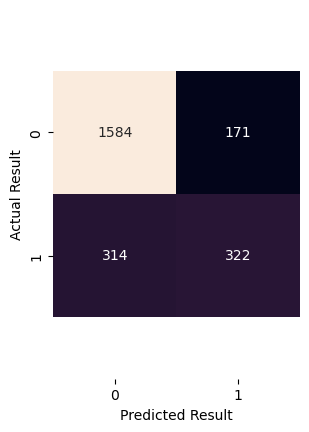

In [231]:
#Confusion matrix viz

predictions = logmodel.predict(X_test)
mat = confusion_matrix(y_test, predictions)
sns.heatmap(mat, fmt='g', square=True, annot=True, cbar=False)
plt.xlabel("Predicted Result")
plt.ylabel("Actual Result")
a, b = plt.ylim() 
a += 0.5 
b -= 0.5 
plt.ylim(a, b)
plt.show()

In [232]:
from sklearn.metrics import confusion_matrix, classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1755
           1       0.65      0.51      0.57       636

    accuracy                           0.80      2391
   macro avg       0.74      0.70      0.72      2391
weighted avg       0.79      0.80      0.79      2391



Model's Accuracy rate is 80%

*b. What is your model’s sensitivity rate?*

Sensitivity likelihood to churn (1) is 51% and not churn(0) is 90%.

*c. What is your model’s specificity rate?*

Specificity rate : 1584/(1584+171)= 1584/1755= 90%

*d. What is your model’s precision?*

Model's precision customers churn rate is 65% and not churn rate is 83%

*e. What is your model’s balanced accuracy?*

Balanced Accuracy is 70%

R. Compare your model’s accuracy against the training set vs. accuracy against the test set (just use accuracy only for this).

*a. What is the purpose of comparing those two values?*

In [233]:
# Calculate the accuracy on the training set
train_accuracy = logmodel.score(X_train, y_train)
print("Accuracy on the training set: {:.2f}%".format(train_accuracy * 100))

# Calculate the accuracy on the test set
test_accuracy = logmodel.score(X_test, y_test)
print("Accuracy on the test set: {:.2f}%".format(test_accuracy * 100))

Accuracy on the training set: 79.19%
Accuracy on the test set: 79.72%


Ans: We compare the training and testing accuracies to better understand how our model is performing. If the accuracies are similar to each other, the model is behaving in a similar way but if they are far from each other than there is a huge difference in their performance.By comparing the accuracy of the model on the training and testing sets, we can get a sense of how well the model is able to generalize to new data and whether it is overfitting or underfitting to the training data. This information can then be used to improve the model, for example, by regularizing the model, collecting more training data, or trying different algorithms.

*b. In this case, what does the comparison of those values suggest about the model that you have built?*

Ans: The comparison between the accuracy of the model on the training set (79.19%) and the test set (79.72%) suggests that the logistic regression model has good generalization ability. This means that the model has learned the underlying patterns in the data well enough that it is able to make accurate predictions on new, unseen data (the test set).
A small difference between the accuracy on the training set and the test set (in this case, an increase of 0.53%) is generally considered a good sign that the model has not overfitted to the training data.

S. For the subscriber that you invented in the previous section, generate a new dataframe to store this person’s info (you will only need values for the variables that you’ve used in this model – so this dataframe will be quite a bit smaller than the one you built previously).  Now, put your subscriber through this model.  

*a. What did your model predict -- will this subscriber churn?*

In [234]:
log_regdf.columns

Index(['tenure', 'MonthlyCharges', 'Churn', 'InternetService_DSL',
       'InternetService_No', 'OnlineSecurity_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'TechSupport_No', 'TechSupport_No internet service',
       'TechSupport_Yes', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [235]:
fictionalsub = pd.DataFrame([{ 'tenure':52,'MonthlyCharges':52.40,'TotalCharges':791.80,
       'InternetService_DSL':0, 'InternetService_Fiber optic':0,
       'InternetService_No':0, 'OnlineSecurity_No':1,
       'OnlineSecurity_No internet service':0, 'OnlineSecurity_Yes':0,'OnlineBackup_No':0,
       'OnlineBackup_No internet service':0, 'OnlineBackup_Yes':1,
       'TechSupport_No':0, 'TechSupport_No internet service':0, 'TechSupport_Yes':1,
       'Contract_Month-to-month':1, 'Contract_One year':0,
       'Contract_Two year':0,
       'PaymentMethod_Bank transfer (automatic)':0,
       'PaymentMethod_Credit card (automatic)':0,
       'PaymentMethod_Electronic check':0, 'PaymentMethod_Mailed check':1}])

fictionalsub

,tenure,MonthlyCharges,TotalCharges,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,...,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,52,52.4,791.8,0,0,0,1,0,0,0,...,0,0,1,1,0,0,0,0,0,1


In [236]:
newprediction_lr = logmodel.predict(fictionalsub)
print(newprediction_lr)

logmodel.predict_proba(fictionalsub).round(2) 

[0]


array([[0.96, 0.04]])

*b. According to your model, what is the probability that this subscriber will churn?*

The probability of subscriber will churn is 4% only while subscriber staying with provider and not churning probability is 96%.

*T. When using a logistic regression model to make predictions, why is it important to only use values within the range of the dataset used to build the model?*

a. Make a new dataframe, but this time, for the numeric predictor variables, select some numbers that are outside the range of the dataset.  Use your model to make a prediction for this new dataframe.  

*What do you notice about the result?*  (To answer this, don’t simply state the predicted outcome, but also write 1-2 sentences of explanation for what you see).  Please -- do not use any 400 year-old vampires named Mary!

Ans : Logistic Regression pushes the values in the range of 0 and 1 - even when we chose values outside the range. Values are hence, choosen within the range so that the model is well-fitted. This is also called interpolation. Logistic regression models are sensitive to outliers, which are extreme values that fall far outside the range of the rest of the data. If the model is used to make predictions on data that includes outliers, it may be influenced by these extreme values, leading to inaccurate predictions. Also Logistic regression models are limited by the data they are trained on. If the model is used to make predictions on values outside the range of the training data, it may not be able to make accurate predictions because it has not been exposed to data in that range. Therefore, to ensure accurate and reliable results, it is best to use logistic regression models within the range of the data used to build the model.

In [237]:
fictionalnum = pd.DataFrame([{ 'tenure':1,'MonthlyCharges':600,'TotalCharges':9220,
       'InternetService_DSL':1, 'InternetService_Fiber optic':1,
       'InternetService_No':0, 'OnlineSecurity_No':0,
       'OnlineSecurity_No internet service':0, 'OnlineSecurity_Yes':1,'OnlineBackup_No':0,
       'OnlineBackup_No internet service':0, 'OnlineBackup_Yes':1,
       'TechSupport_No':0, 'TechSupport_No internet service':1, 'TechSupport_Yes':1,
       'Contract_Month-to-month':1, 'Contract_One year':0,
       'Contract_Two year':0,
       'PaymentMethod_Bank transfer (automatic)':0,
       'PaymentMethod_Credit card (automatic)':0,
       'PaymentMethod_Electronic check':0, 'PaymentMethod_Mailed check':1}])

fictionalnum

,tenure,MonthlyCharges,TotalCharges,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,...,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,600,9220,1,1,0,0,0,1,0,...,0,1,1,1,0,0,0,0,0,1


In [238]:
numpredict_lr = logmodel.predict(fictionalnum)
print(numpredict_lr)

logmodel.predict_proba(fictionalnum).round(2) 

[1]


array([[0.28, 0.72]])

Ans: Upon chosing values outside the range, the model gave a prediction of customer churning. With a 72% probability of the customer churning. This is because in the regression model prediction within the range determines the model fit. If the values go outside the range then it is known as extrapolation. The further the values are, the higher the the chances of the model to fail due to differences in predicted and actual values.

U. For this question, no Python code is required -- just use a Markdown cell to answer.  *Write a 3-5 sentence paragraph that speculates about why the telephone company might care about being able to use this particular model.*  There is not a single "correct" answer to this question.  Be thoughtful and be creative, and **focus on the impact of being able to predict a particular subscriber’s likelihood of renewal**.  You can mention a marketing angle, an operations angle, or anything else that comes to mind.

From Marketing perspective, customer retention and attraction is everything and there are so many factors involved in predicting customer behaviour. With the enormous amount of data being fed to these models, they are becoming smarter than humans when it comes to predicting our actions. I feel these models are actually useful in predicting consumer behaviour based on different variables. The ability to predict a subscriber's likelihood of renewal with this model could be extremely valuable for the telephone company. Company could use this information to develop targeted retention campaigns for customers who are at high risk of churning, potentially saving the company a significant amount of revenue by reducing churn. Additionally, from an operational perspective, this model could help the company allocate resources more effectively by focusing on customer service and engagement for customers who are most likely to leave. Overall, the ability to accurately predict churn could help the company better understand customer behavior and make more informed decisions to improve customer satisfaction and retention.
Also knowing the probability of outcome can help in simplifying the problem and find more targeted solution. It is also easier to group probabilities into categories to do that.
         If i were in charge of Marketing team for this telephone comapny, I would use the probabilities to better understand the factors or variables that are affecting the decision of my target audience. I would then leverage on those variables and launch campaigns that would cater to their needs. For one small example, i would offere incentive of first 2 month free when signing long term contracts or for monthly subscriber providing a call back service for solving any issue rather than them waiting on line when calling for inquiry or issue. Altering different marketing and customer service strategy based on different type of audience can benefit greatly for telephone company in long term gaining profit and customer retention.
